In [1]:
import pandas as pd
import os
from pathlib import Path
import matplotlib.pyplot as plot


In [ ]:
# os.chdir(Path.cwd().parent)
os.getcwd()


'c:\\Users\\Tomas\\Desktop\\Thesis Stuff\\Coding'

In [3]:
from src import constants as const
from src.data_cleaning import DataCleaner
from src.data_processing import DataProcessor
from src.plotting import PlottingData

__Step 1__ 
Merging vehicle and activity dataframes
Rows after merge: 88763
Missing vehicle_id values after merge: 801

__Step 2__ 
Filtering rows with missing values in columns: ['vehicle_id']
Rows before NaN filtering: 88763
Rows after NaN filtering: 87962
Rows removed: 801

__Step 3__ 
Filtering activity after inactivity threshold: 30 days
Rows before inactivity filtering: 87962
Rows after inactivity filtering: 43523
Rows removed: 44439
Unique users before: 100
Unique users after: 100
Churn-triggering rows: 76

__Step 4__ 
Filtering by user type: personal-use users
Vehicle count threshold: 2
Rows before user type filtering: 43523
Rows after user type filtering: 1368
Rows removed: 42155
Unique users before: 100
Unique users after: 27

Cleaning complete
Final rows: 1368
Final unique users: 27

tenure_days
30    7
51    2
Name: churned, dtype: int64


In [4]:
activity_df = pd.read_csv(const.PATH_TO_RAW_ACTIVITY_DATA)
user_df = pd.read_csv(const.PATH_TO_RAW_USER_DATA)
vehicle_df = pd.read_csv(const.PATH_TO_RAW_VEHICLE_DATA)

In [5]:
activity_df.head()

,user_id,vehicle_id,activity_date,app,activity_type
0,455fc4e611d63fe7bf86c9ecde11f5882d0d2660ba1958...,907697f673362032cd5f17633e26b8402072b29d1f6de4...,2024-04-13T13:46:51.738Z,VAG,coding
1,5d68c02c2419ad38b7414d4d58cde5c1f694ccadbdd05d...,add15baf05ac03d54b52253e3e452fe262bad0aca71598...,2022-08-11T00:15:10.608Z,VAG,scan
2,4fbe8ffbe8f62e67c2956e124841da95c25cffb6144661...,1295bcf9367564067b98b8028b0894ddfb3c73130af9c9...,2024-08-06T14:10:00.200Z,VAG,coding
3,e33170b57f86fd844247e4bc1f40607691f0d33db4f85a...,f5a25fe3392ff4695b56ba1b723e1829b2e64fb8244e35...,2025-08-12T12:10:36.628Z,VAG,scan
4,4fbe8ffbe8f62e67c2956e124841da95c25cffb6144661...,143ad173df0df62fcb705c85b6bfe4c347f90758b60a73...,2024-08-04T11:25:32.723Z,VAG,coding


In [6]:
data_cleaner = DataCleaner(activity_df,
                           vehicle_df)

full_df = data_cleaner.get_clean_data()

full_df.head()
print(len(full_df))

full_df.isna().sum()


full_df["vehicle_id"].isna().sum()



__Step 1__ 
Merging vehicle and activity dataframes
Rows after merge: 88763
Missing vehicle_id values after merge: 801

Cleaning complete
Final rows: 88763
Final unique users: 100

88763


np.int64(801)

__Step 1__ 
Merging vehicle and activity dataframes
Rows after merge: 88763
Missing vehicle_id values after merge: 801

__Step 2__ 
Filtering by user type: non-personal-use users
Vehicle count threshold: 2
Rows before user type filtering: 88763
Rows after user type filtering: 85111
Rows removed: 3652
Unique users before: 100
Unique users after: 93

Cleaning complete
Final rows: 85111
Final unique users: 93

__Step 1__ 
Using activity dataframe without merging
Rows: 85111

__Step 2__ 
Filtering activity after inactivity threshold: 30 days
Rows before inactivity filtering: 85111
Rows after inactivity filtering: 43589
Rows removed: 41522
Unique users before: 93
Unique users after: 93
Churn-triggering rows: 69

Cleaning complete
Final rows: 43589
Final unique users: 93



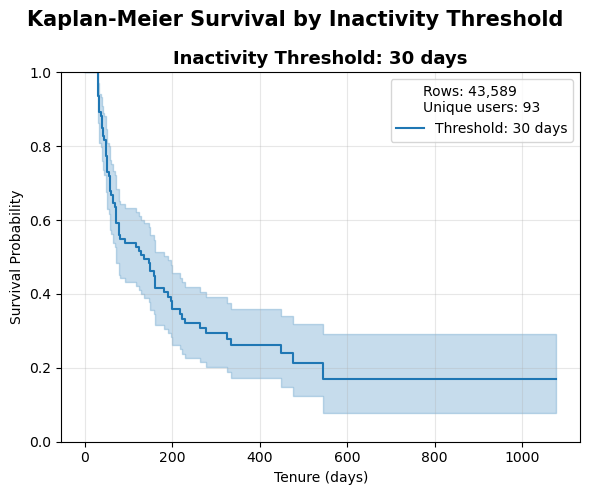

In [7]:
data_cleaner = DataCleaner(activity_df,
                           vehicle_df)

full_df = data_cleaner.get_clean_data(merge_data_frames=True,
                                      filter_by_user_type=True,
                                      unique_vehicle_count_threshold=2)



plotting = PlottingData()
fig,ax = plotting.plot_kpm_curve(full_df,thresholds=[30])

plot.show()

__Step 1__ 
Merging vehicle and activity dataframes
Rows after merge: 88763
Missing vehicle_id values after merge: 801

__Step 2__ 
Filtering by user type: personal-use users
Vehicle count threshold: 5
Rows before user type filtering: 88763
Rows after user type filtering: 18444
Rows removed: 70319
Unique users before: 100
Unique users after: 24

Cleaning complete
Final rows: 18444
Final unique users: 24

__Step 1__ 
Using activity dataframe without merging
Rows: 18444

__Step 2__ 
Filtering activity after inactivity threshold: 30 days
Rows before inactivity filtering: 18444
Rows after inactivity filtering: 6894
Rows removed: 11550
Unique users before: 24
Unique users after: 24
Churn-triggering rows: 22

Cleaning complete
Final rows: 6894
Final unique users: 24

__Step 1__ 
Using activity dataframe without merging
Rows: 18444

__Step 2__ 
Filtering activity after inactivity threshold: 60 days
Rows before inactivity filtering: 18444
Rows after inactivity filtering: 12462
Rows removed: 59

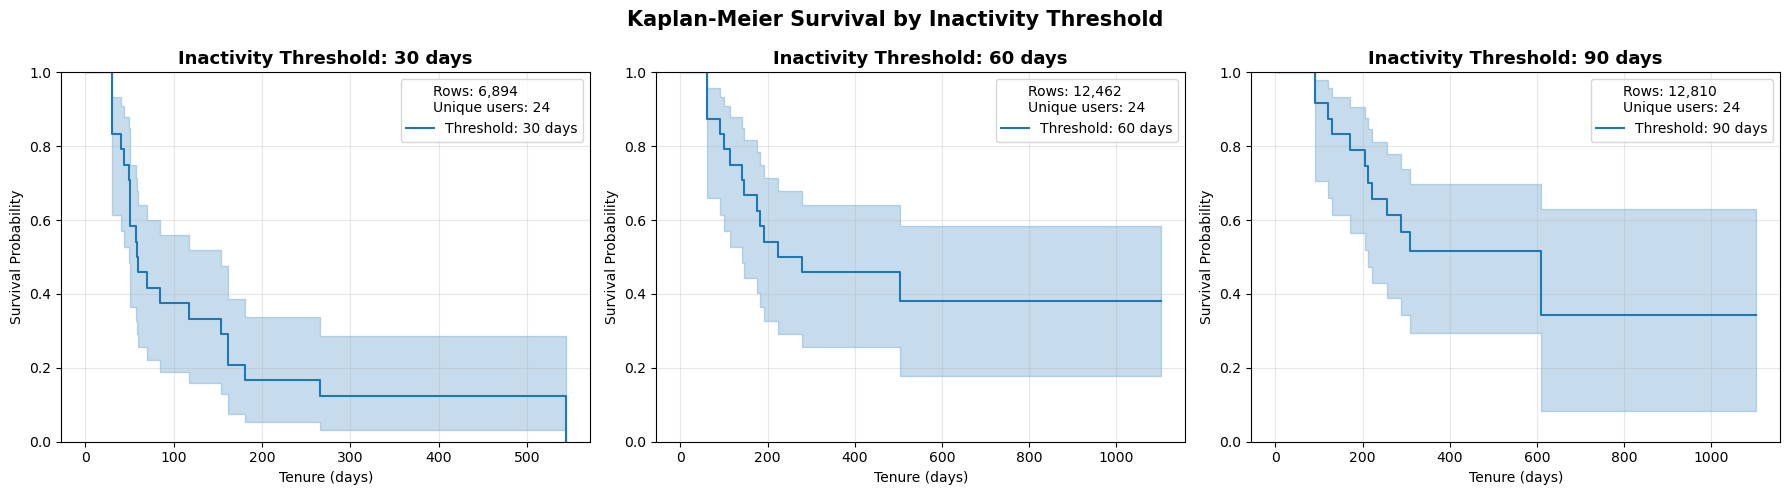

In [8]:
data_cleaner = DataCleaner(activity_df,
                           vehicle_df)

df = data_cleaner.get_clean_data(merge_data_frames=True,filter_by_user_type=True,return_personal_use_users=True, unique_vehicle_count_threshold=5)



plotting = PlottingData()
fig, ax = plotting.plot_kpm_curve(df,[30,60,90])

plot.show()

In [9]:
data_cleaner_2 = DataCleaner(df,pd.DataFrame())


df_filtered = data_cleaner_2.get_clean_data(merge_data_frames=False, filter_inactivity=True)


df_filtered.groupby("user_id")["activity_date"].count()


df_filtered[df_filtered["user_id"] == "5abab24601d3816eb76e451ad562376b35205b7c99e2e49f3889387c84fa5d69"]

__Step 1__ 
Using activity dataframe without merging
Rows: 18444

__Step 2__ 
Filtering activity after inactivity threshold: 30 days
Rows before inactivity filtering: 18444
Rows after inactivity filtering: 6894
Rows removed: 11550
Unique users before: 24
Unique users after: 24
Churn-triggering rows: 22

Cleaning complete
Final rows: 6894
Final unique users: 24



,vehicle_id,user_id,vehicle_make,vehicle_model,vehicle_start_year,vehicle_end_year,vehicle_mileage,activity_date,app,activity_type,churn_triggered,event_date
58473,8ec742e7fab5d57f812808ddfa2a987d96d91ce8ac301f...,5abab24601d3816eb76e451ad562376b35205b7c99e2e4...,Volkswagen,Golf,2012.0,2017.0,200000-250000,2025-04-24 18:51:10.976000+00:00,VAG,scan,False,2025-04-24 18:51:10.976000+00:00
71587,8ec742e7fab5d57f812808ddfa2a987d96d91ce8ac301f...,5abab24601d3816eb76e451ad562376b35205b7c99e2e4...,Volkswagen,Golf,2012.0,2017.0,200000-250000,2025-04-24 18:51:29.975000+00:00,VAG,oca,False,2025-04-24 18:51:29.975000+00:00
75526,dccd26803df542d27fce28141648436090457ba31aa55b...,5abab24601d3816eb76e451ad562376b35205b7c99e2e4...,NaN,NaN,NaN,NaN,NaN,2025-09-04 21:47:28.059000+00:00,MAIN,oca,True,2025-05-24 18:51:29.975000+00:00


__Step 1__ 
Using activity dataframe without merging
Rows: 85111

__Step 2__ 
Filtering activity after inactivity threshold: 30 days
Rows before inactivity filtering: 85111
Rows after inactivity filtering: 43589
Rows removed: 41522
Unique users before: 93
Unique users after: 93
Churn-triggering rows: 69

Cleaning complete
Final rows: 43589
Final unique users: 93



(<Figure size 800x500 with 1 Axes>,
 <Axes: title={'center': 'Tied Churn Events by Tenure Day (Threshold: 30 days)'}, xlabel='Tenure days', ylabel='Number of churn events'>)

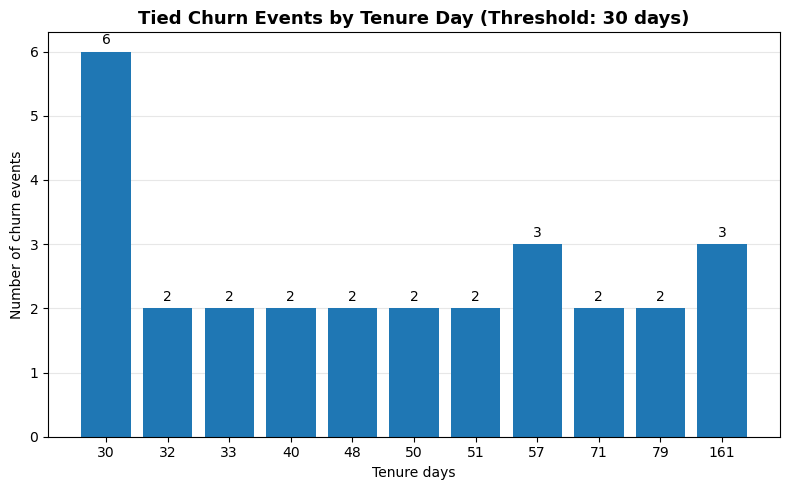

In [11]:
data_cleaner_2 = DataCleaner(full_df, pd.DataFrame())
threshold_value = 30
data_processor = DataProcessor(data_cleaner_2.get_clean_data(merge_data_frames=False, filter_inactivity=True,threshold_value=threshold_value))
ties = data_processor.calculate_ties()
plotting.plot_tie_graph(ties,title=f"Tied Churn Events by Tenure Day (Threshold: {threshold_value} days)")

__Step 1__ 
Merging vehicle and activity dataframes
Rows after merge: 88763
Missing vehicle_id values after merge: 801

__Step 2__ 
Filtering by user type: personal-use users
Vehicle count threshold: 2
Rows before user type filtering: 88763
Rows after user type filtering: 3652
Rows removed: 85111
Unique users before: 100
Unique users after: 7

Cleaning complete
Final rows: 3652
Final unique users: 7

__Step 1__ 
Merging vehicle and activity dataframes
Rows after merge: 88763
Missing vehicle_id values after merge: 801

__Step 2__ 
Filtering by user type: non-personal-use users
Vehicle count threshold: 2
Rows before user type filtering: 88763
Rows after user type filtering: 85111
Rows removed: 3652
Unique users before: 100
Unique users after: 93

Cleaning complete
Final rows: 85111
Final unique users: 93



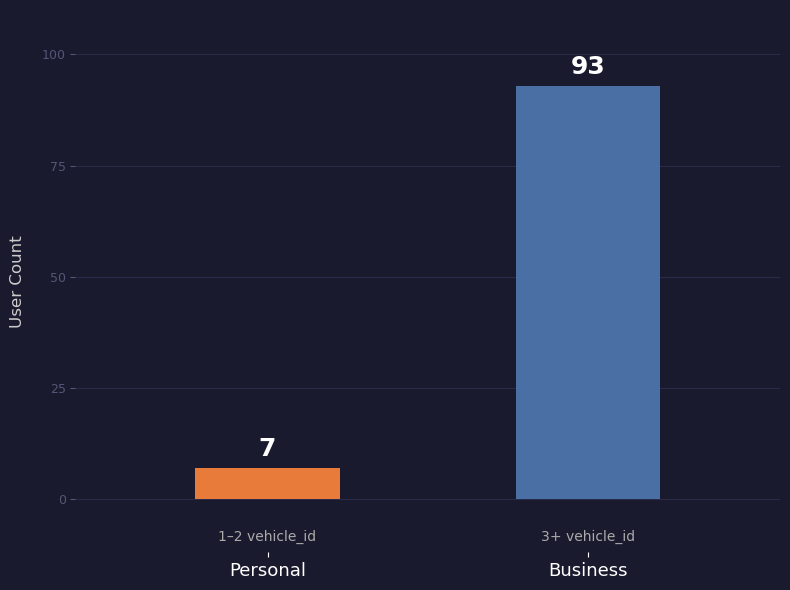

In [17]:
personal_users = data_cleaner.get_clean_data(filter_by_user_type=True,return_personal_use_users=True)
business_users = data_cleaner.get_clean_data(filter_by_user_type=True,return_personal_use_users=False)


import matplotlib.pyplot as plt

# Data
groups = ['Personal', 'Business']
counts = [7, 93]
colors = ['#E87B3A', '#4A6FA5']

fig, ax = plt.subplots(figsize=(8, 6))
fig.patch.set_facecolor('#1a1a2e')
ax.set_facecolor('#1a1a2e')

bars = ax.bar(groups, counts, color=colors, width=0.45, zorder=3)

for bar, color in zip(bars, colors):
    bar.set_edgecolor('none')

# Value labels on top
for bar, count in zip(bars, counts):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 1.5,
            str(count), ha='center', va='bottom',
            color='white', fontsize=18, fontweight='bold', fontfamily='sans-serif')

# Subtitles below x labels
subtitles = ['1–2 vehicle_id', '3+ vehicle_id']
for bar, subtitle in zip(bars, subtitles):
    ax.text(bar.get_x() + bar.get_width() / 2, -7,
            subtitle, ha='center', va='top',
            color='#aaaaaa', fontsize=10, fontfamily='sans-serif')

# Styling
ax.set_ylim(-12, 110)
ax.set_xlim(-0.6, 1.6)
ax.set_ylabel('User Count', color='#cccccc', fontsize=12, labelpad=12)
ax.tick_params(colors='white', labelsize=12)
for label in ax.get_xticklabels():
    label.set_color('white')
    label.set_fontsize(13)
for spine in ax.spines.values():
    spine.set_visible(False)


ax.set_yticks([0, 25, 50, 75, 100])
ax.yaxis.set_tick_params(colors='#444466')
ax.grid(axis='y', color='#2a2a4a', linewidth=0.8, zorder=0)
ax.tick_params(axis='y', colors='#555577', labelsize=9)

plt.tight_layout()
plt.savefig('user_groups_bar.png', dpi=150, bbox_inches='tight', facecolor='#1a1a2e')
plt.show()